# EfficientNet

In [3]:
pip install datasets tqdm torch torchaudio torchcodec torchmetrics transformers ffmpeg-python ffmpeg scikit-learn seaborn librosa torch-audiomentations audiomentations torchvision wandb


  Using cached datasets-4.5.0-py3-none-any.whl.metadata (19 kB)
  Using cached torchaudio-2.10.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (6.9 kB)
  Using cached torchcodec-0.10.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached torchmetrics-1.8.2-py3-none-any.whl.metadata (22 kB)
  Using cached transformers-5.0.0-py3-none-any.whl.metadata (37 kB)
  Using cached ffmpeg_python-0.2.0-py3-none-any.whl.metadata (1.7 kB)
  Using cached ffmpeg-1.4-py3-none-any.whl
  Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached torch_audiomentations-0.12.0-py3-none-any.whl.metadata (15 kB)
  Using cached audiomentations-0.43.1-py3-none-any.whl.metadata (11 kB)
  Using cached torchvision-0.25.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (5.4 kB)
  Using cached wandb-0.24.0-p

In [4]:
from pathlib import Path
from typing import Union

import pandas as pd
import torch
from cryptography.hazmat.primitives.keywrap import aes_key_wrap
from torch import nn, optim, Tensor
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
import torchmetrics
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_from_disk, DatasetDict, load_dataset, Dataset, ClassLabel
import torchaudio
import torchaudio.transforms as T
import random
import torchcodec
import torchaudio
import datasets
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import torch_audiomentations as ta
import torch
import torch.nn as nn
from torch_audiomentations import Compose, AddColoredNoise, PitchShift, Shift
import numpy as np
from datasets import concatenate_datasets
import wandb
from torchvision import models

api = wandb.Api()

SEED = 42
SAMPLE_RATE = 16000
BATCH_SIZE = 32
NUM_WORKERS = 96
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.


In [5]:
ds = load_dataset("Hibou-Foundation/big_ds_4_raw_wav_balanced")
# ("Hibou-Foundation/ds_10_raw_aug_0-5_balanced_chunked")
# ("Hibou-Foundation/big_ds_5_specto_noaug_chunked_balanced")


In [6]:
print(ds)


DatasetDict({
    train: Dataset({
        features: ['audio', 'label'],
        num_rows: 352116
    })
    val: Dataset({
        features: ['audio', 'label'],
        num_rows: 43580
    })
    test: Dataset({
        features: ['audio', 'label'],
        num_rows: 43478
    })
})


In [7]:
LABELS = ds["train"].features["label"]


In [72]:
# Preprocessing
# We are doing :
# - Convert stereo to mono
# - Melspectogram
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=1024,
    hop_length=256,
    n_mels=128,
)
db_transform = torchaudio.transforms.AmplitudeToDB()

def preprocess(item: Union[dict, torch.Tensor]):
    if isinstance(item, dict):
        audio = item["audio"]
        if isinstance(audio, AudioDecoder):
            waveform = torch.tensor(audio["array"]).float()
        else:
            waveform = torch.tensor(audio).float()
    else:
        waveform = item

    # Convert stereo → mono
    if waveform.ndim > 1:
        waveform = waveform.mean(dim=0)

    mel = mel_transform(waveform)
    mel_db = db_transform(mel)

    return mel_db

import torchaudio.transforms as T
import torch
from typing import Union

spec_transform = T.Spectrogram(
    n_fft=1024, # 2048
    hop_length=512,# 512
    power=2.0,       # power spectrogram
)

db_transform = T.AmplitudeToDB()

def preprocess(item: Union[dict, torch.Tensor]):
    if isinstance(item, dict):
        audio = item["audio"]
        if isinstance(audio, torchcodec.decoders.AudioDecoder):
            waveform = audio.get_all_samples().data.float()
        else:
            waveform = torch.tensor(audio).float()
    else:
        waveform = item

    # Convert stereo → mono
    if waveform.ndim > 1:
        waveform = waveform.mean(dim=0)

    spec = spec_transform(waveform)
    spec_db = db_transform(spec)

    return spec_db


In [73]:
def collate_fn(batch):
    xs = []
    ys = []

    for b in batch:
        mel_db = preprocess(b)
        xs.append(mel_db)
        ys.append(b["label"])

    # Dynamically determine frequency (F) and time (T)
    max_freq = max(x.shape[-2] for x in xs)
    max_time = max(x.shape[-1] for x in xs)

    # Create padded batch
    xs_padded = torch.zeros((len(xs), 1, max_freq, max_time))

    for i, x in enumerate(xs):
        f, t = x.shape
        xs_padded[i, 0, :f, :t] = x

    ys = torch.tensor(ys)
    return xs_padded, ys


train_loader = DataLoader(ds["train"], batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn)
valid_loader = DataLoader(ds["val"], batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn)
test_loader = DataLoader(ds["test"], batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, collate_fn=collate_fn)


In [77]:
class EfficientNetB0AudioClassifier(nn.Module):
    """
    EfficientNet B0 model adapted for audio classification.
    
    This model uses a pre-trained EfficientNet B0 as a backbone and modifies it
    for audio classification tasks. Audio is typically converted to spectrograms
    (mel-spectrograms, MFCCs, etc.) which can be treated as images.
    
    Args:
        num_classes (int): Number of output classes for classification
        pretrained (bool): Whether to use ImageNet pre-trained weights
        in_channels (int): Number of input channels (1 for mono, 3 for RGB spectrograms)
        dropout (float): Dropout probability for the classifier head
    """
    
    def __init__(self, num_classes, pretrained=True, in_channels=1, dropout=0.2):
        super(EfficientNetB0AudioClassifier, self).__init__()
        
        # Load pre-trained EfficientNet B1
        if pretrained:
            weights = models.EfficientNet_B1_Weights.DEFAULT
            self.backbone = models.efficientnet_b1(weights=weights)
        else:
            self.backbone = models.efficientnet_b1(weights=None)

        # Modify the first convolutional layer if input channels != 3
        if in_channels != 3:
            original_conv = self.backbone.features[0][0]
            self.backbone.features[0][0] = nn.Conv2d(
                in_channels,
                original_conv.out_channels,
                kernel_size=original_conv.kernel_size,
                stride=original_conv.stride,
                padding=original_conv.padding,
                bias=False
            )

            # If using pretrained weights, initialize new conv layer intelligently
            if pretrained and in_channels == 1:
                # Average the RGB weights for single channel input
                with torch.no_grad():
                    self.backbone.features[0][0].weight = nn.Parameter(
                        original_conv.weight.mean(dim=1, keepdim=True)
                    )

        # Replace the classifier head
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        """
        Forward pass

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, channels, height, width)
                             For audio: typically spectrograms with shape (B, 1, H, W) or (B, 3, H, W)

        Returns:
            torch.Tensor: Output logits of shape (batch_size, num_classes)
        """
        return self.backbone(x)

    def get_features(self, x):
        """
        Extract features before the classification head

        Args:
            x (torch.Tensor): Input tensor

        Returns:
            torch.Tensor: Feature embeddings
        """
        x = self.backbone.features(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        return x


In [78]:
def create_efficientnet_audio_model(num_classes, pretrained=True, in_channels=1, dropout=0.2):
    """
    Helper function to create an EfficientNet B0 audio classifier
    
    Args:
        num_classes (int): Number of output classes
        pretrained (bool): Use ImageNet pre-trained weights
        in_channels (int): Number of input channels (1 for mono spectrograms)
        dropout (float): Dropout rate
    
    Returns:
        EfficientNetB0AudioClassifier: The model instance
    """
    return EfficientNetB0AudioClassifier(
        num_classes=num_classes,
        pretrained=pretrained,
        in_channels=in_channels,
        dropout=dropout
    )


In [79]:
model = create_efficientnet_audio_model(num_classes=2).to(DEVICE)
print(model)


EfficientNetB0AudioClassifier(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
   

In [80]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
metric_acc = torchmetrics.classification.MulticlassAccuracy(num_classes=2).to(DEVICE)


In [81]:
EPOCHS = 5
best_val_acc = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss, train_acc = 0, 0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)
        train_acc += metric_acc(out, y) * x.size(0)

    scheduler.step()
    train_loss /= len(ds["train"])
    train_acc = train_acc / len(ds["train"])

    # Validation
    model.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for x, y in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item() * x.size(0)
            val_acc += metric_acc(out, y) * x.size(0)

    val_loss /= len(ds["val"])
    val_acc = val_acc / len(ds["val"])

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
            },
            "./effnet.b1.3.pt"
        )
        print("✅ Saved new best model!")


Epoch 1/5 [Valid]: 100%|██████████| 681/681 [00:33<00:00, 20.23it/s]


Epoch 1/5 | Train Loss: 0.0375 | Train Acc: 0.9881 | Val Loss: 0.0411 | Val Acc: 0.9908
✅ Saved new best model!


Epoch 2/5 [Valid]: 100%|██████████| 681/681 [00:34<00:00, 20.02it/s]


Epoch 2/5 | Train Loss: 0.0150 | Train Acc: 0.9953 | Val Loss: 0.0404 | Val Acc: 0.9924
✅ Saved new best model!


Epoch 3/5 [Valid]: 100%|██████████| 681/681 [00:34<00:00, 19.70it/s]


Epoch 3/5 | Train Loss: 0.0097 | Train Acc: 0.9971 | Val Loss: 0.0511 | Val Acc: 0.9923


Epoch 4/5 [Valid]: 100%|██████████| 681/681 [00:34<00:00, 20.02it/s]


Epoch 4/5 | Train Loss: 0.0064 | Train Acc: 0.9981 | Val Loss: 0.0538 | Val Acc: 0.9925
✅ Saved new best model!


Epoch 5/5 [Valid]: 100%|██████████| 681/681 [00:34<00:00, 19.65it/s]


Epoch 5/5 | Train Loss: 0.0041 | Train Acc: 0.9987 | Val Loss: 0.0378 | Val Acc: 0.9930
✅ Saved new best model!


In [89]:
checkpoint = torch.load("./effnet.b1.3.pt", map_location=torch.device("cuda"), weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()


EfficientNetB0AudioClassifier(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
   

In [90]:
ds_all_tests = load_dataset("Hibou-Foundation/drone_all_test_datasets")
ds_test_1 = ds_all_tests["drone_test"]
ds_test_2 = ds_all_tests["drone_test_2"]
ds_parabole_1 = ds_all_tests["mic_parabole"]
ds_parabole_2 = ds_all_tests["parabole2"]
test_dataset = ds['test']


In [91]:
print(ds["train"].features["label"])


ClassLabel(names=['other', 'drone'])


In [92]:
print(ds["val"].features["label"])


ClassLabel(names=['other', 'drone'])


In [93]:
model.eval()


EfficientNetB0AudioClassifier(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
   

In [94]:
run = wandb.init(entity="hibou", project="acoustic", name="EfficientNetB1Spec2")


In [95]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import wandb
from tqdm import tqdm
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64
NUM_WORKERS = 4

def run_tests(sets, upload=False):
    model.to(DEVICE)
    model.eval()

    names = ['no_drone', 'drone']

    for dataset, name in sets:
        dl = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            collate_fn=collate_fn,   # keep this if you really need it
        )

        y_true, y_pred = [], []

        with torch.no_grad():
            for x, y in tqdm(dl, desc=name):
                x = x.to(DEVICE)
                y = y.to(DEVICE)

                out = model(x)
                preds = out.argmax(dim=1)

                # Convert to plain Python lists
                y_true.extend(y.cpu().tolist())
                y_pred.extend(preds.cpu().tolist())

        print("\n\n" + "="*10, name, "="*10 + "\n\n")
        print(
            classification_report(
                y_true, y_pred,
                target_names=names,
                digits=3
            )
        )

        cm = confusion_matrix(y_true, y_pred)

        if upload:
            upload_name = name + "/confusion_matrix"
            run.log({
                upload_name: wandb.plot.confusion_matrix(
                    y_true=y_true,
                    preds=y_pred,
                    class_names=names,
                    title=f"Confusion Matrix - {name}"
                )
            })

        plt.figure(figsize=(10, 8))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            xticklabels=names,
            yticklabels=names
        )
        plt.xlabel("Prediction")
        plt.ylabel("Truth")
        plt.title(f"Confusion Matrix - {name}")
        plt.tight_layout()
        plt.show()


In [96]:
l = [(ds_test_1, "test_online_1"), (ds_test_2, "test_online_2"), (ds_parabole_1, "test_parabole"), (ds_parabole_2, "test_parabole2"), (test_dataset, "test")]


test_online_1: 100%|██████████| 14/14 [00:00<00:00, 25.87it/s]




========== test_online_1 ==========


              precision    recall  f1-score   support

    no_drone      0.615     1.000     0.761       509
       drone      1.000     0.169     0.290       384

    accuracy                          0.643       893
   macro avg      0.807     0.585     0.525       893
weighted avg      0.780     0.643     0.558       893



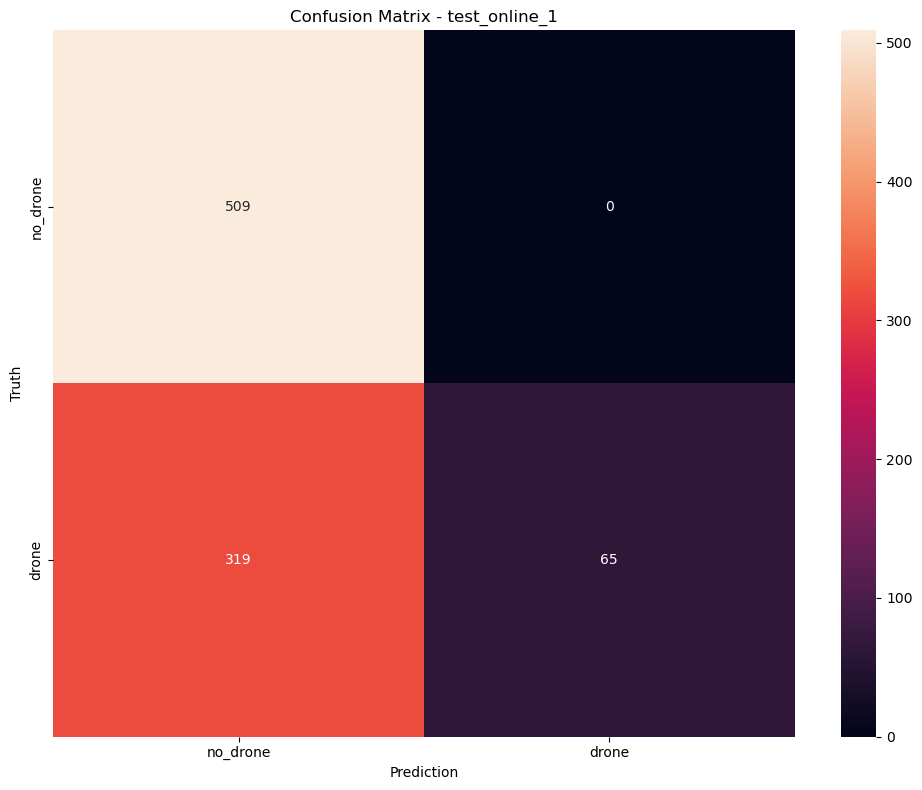

test_online_2: 100%|██████████| 44/44 [00:00<00:00, 45.48it/s]




========== test_online_2 ==========


              precision    recall  f1-score   support

    no_drone      0.006     1.000     0.011         1
       drone      1.000     0.937     0.968      2804

    accuracy                          0.937      2805
   macro avg      0.503     0.969     0.489      2805
weighted avg      1.000     0.937     0.967      2805



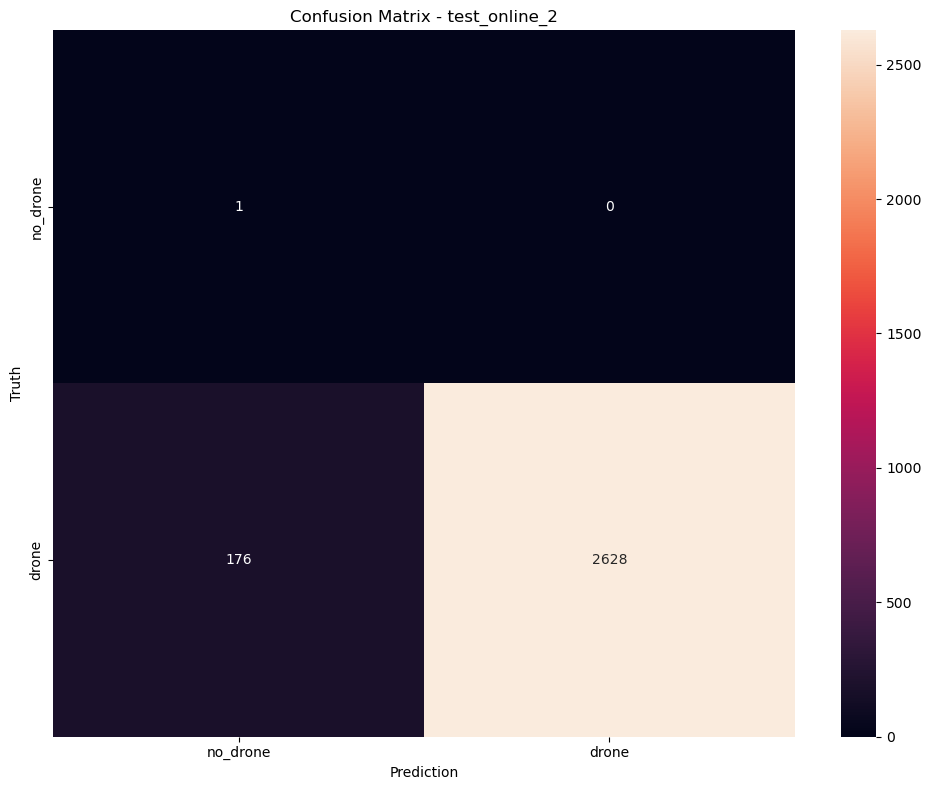

test_parabole: 100%|██████████| 2/2 [00:00<00:00,  5.33it/s]




========== test_parabole ==========


              precision    recall  f1-score   support

    no_drone      0.375     1.000     0.545        45
       drone      1.000     0.038     0.074        78

    accuracy                          0.390       123
   macro avg      0.688     0.519     0.310       123
weighted avg      0.771     0.390     0.247       123



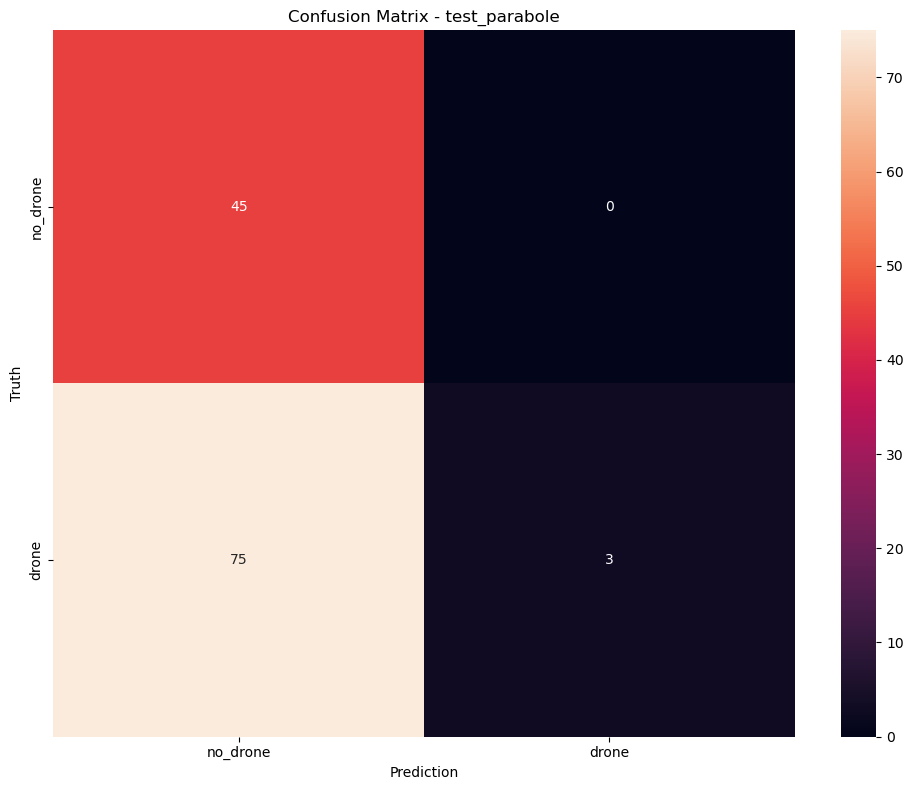

test_parabole2: 100%|██████████| 2/2 [00:00<00:00,  5.50it/s]




========== test_parabole2 ==========


              precision    recall  f1-score   support

    no_drone      0.400     1.000     0.571        26
       drone      1.000     0.339     0.506        59

    accuracy                          0.541        85
   macro avg      0.700     0.669     0.539        85
weighted avg      0.816     0.541     0.526        85



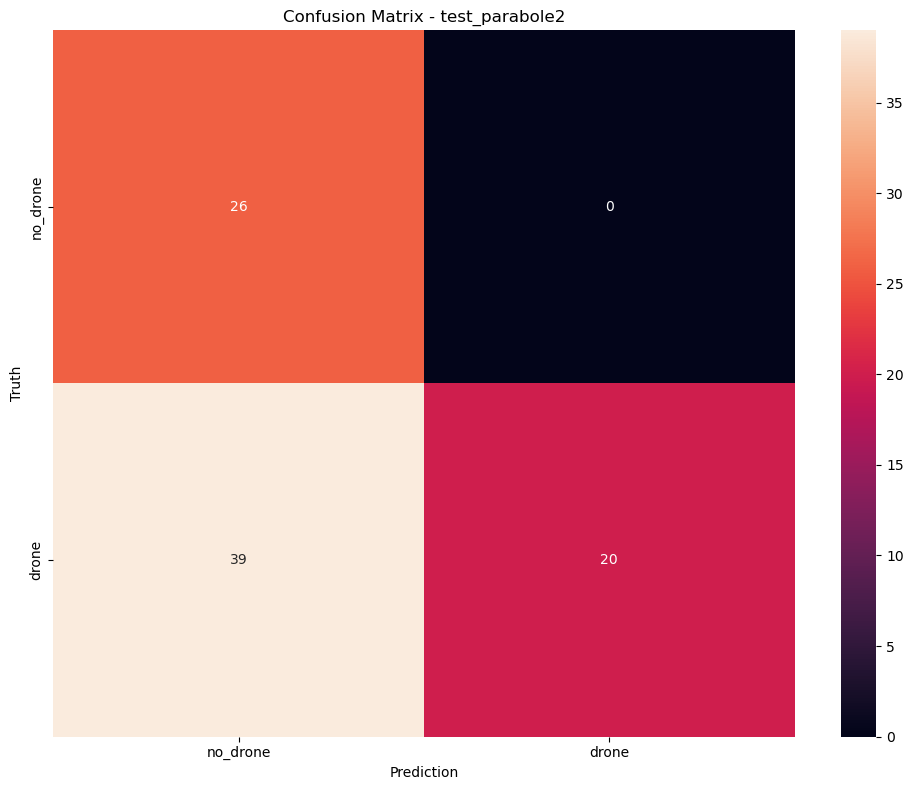

test: 100%|██████████| 680/680 [00:33<00:00, 20.15it/s]




========== test ==========


              precision    recall  f1-score   support

    no_drone      0.997     0.994     0.996     21739
       drone      0.994     0.997     0.996     21739

    accuracy                          0.996     43478
   macro avg      0.996     0.996     0.996     43478
weighted avg      0.996     0.996     0.996     43478



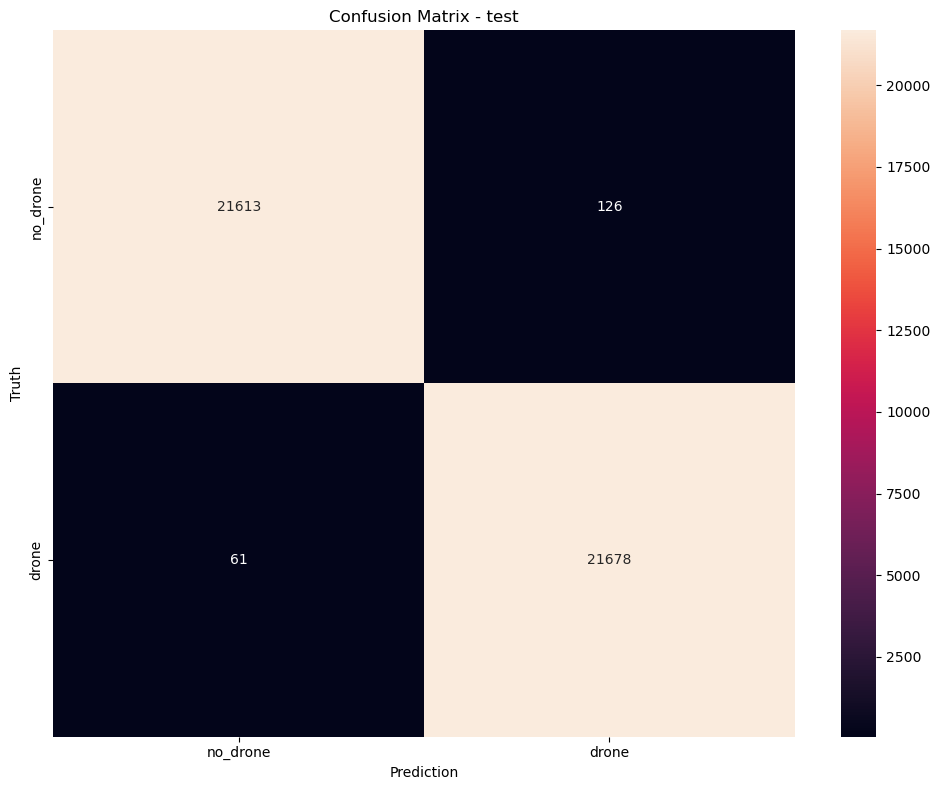

In [97]:
run_tests(l, upload=True)
